In [97]:
import numpy as np
import numpy.linalg as linalg
from obspy.imaging.beachball import beachball

In [98]:
eps = 1e-10; halfpi = np.pi/2; twopi = 2*np.pi
i_hat = np.array([1,0,0]); j_hat = np.array([0,1,0]); k_hat = np.array([0,0,1])

def unit_vec(vector: list) -> list:
    ''' Returns the unit vector of a vector. '''
    return vector / linalg.norm(vector)

def rotate_vec(vec: list, axis: list, theta: float) -> list:
    '''
    Rotate vec around axis by theta RADIANS, counterclockwise.
    Axis must be a unit vector.
    '''
    rotated_vec = vec*np.cos(theta) + (np.cross(axis,vec))*np.sin(theta) + \
        axis*(axis @ vec)*(1-np.cos(theta))
    
    return rotated_vec

def pol2rect(pol: list) -> list:
    '''
    Converts from polar/spherical to rectangular coordinates.

    Args:
        pol (list[int]): polar/spherical coordinates
    '''
    r = pol[0]
    theta = pol[1]
    
    if len(pol) == 2:
        x = r*np.cos(theta)
        y = r*np.sin(theta)
        return np.array([x,y])
    
    phi = pol[2]
    
    x = r*np.cos(theta)*np.sin(phi)
    y = r*np.sin(theta)*np.sin(phi)
    z = r*np.cos(phi)
    
    return np.array([x,y,z])

def rect2pol(rect: list) -> list:
    '''
    Converts from rectangular to polar/spherical coordinates.

    Args:
        rect (list): rectangular coordinates
    '''
    
    if len(rect) == 2:
        x, y = rect
        r = linalg.norm(rect)
        theta = np.arctan2(y, x) % twopi
        return np.array([r, theta])
    
    x, y, z = rect
    rho = linalg.norm(rect)
    theta = np.arctan2(y, x) % twopi
    phi = np.arctan2(np.sqrt(x**2 + y**2), z)
    
    return np.array([rho, theta, phi])

def bearing2angle(bearing: float) -> float:
    '''
    Converts bearing to angle (unit circle).
    Angles in RADIANS.

    Args:
        bearing (float): bearing in RADIANS, N = y axis
    '''
    bearing = twopi - bearing
    angle = (bearing + halfpi) % twopi
    
    return angle

def sdr2tp(sdr: list, deg: bool = False) -> tuple:
    '''
    Converts from strike, dip, and rake to T and P axes.

    Args:
        sdr (list): strike, dip, and rake
        deg (bool, optional): input in degrees if True

    Returns:
        tuple: (t, p) as unit vectors in x, y, z
    '''
    if deg: sdr = np.deg2rad(sdr)
    
    # first normal from strike and dip
    strike, dip, rake = sdr
    
    n1_theta = bearing2angle(strike + halfpi)
    n1_phi = dip
    n1 = pol2rect(np.array([1, n1_theta, n1_phi]))

    n2_theta = bearing2angle(strike)
    n2_init = pol2rect(np.array([1, n2_theta, halfpi]))
    n2 = rotate_vec(n2_init, n1, rake)
    
    # get T and P axes
    t = (n1 + n2)/linalg.norm(n1 + n2)
    p = (n1 - n2)/linalg.norm(n1 - n2)
    
    # restrict to upper hemisphere
    if t[2] < 0: t *= -1
    if p[2] < 0: p *= -1
    
    return t, p

def tp2sdr(t: list, p: list, deg: bool = False) -> tuple:
    '''
    Converts from T and P axes to strike, dip, and rake of both fault planes
    Inputs are numpy arrays, assumes unit vectors
    Uses right-hand rule for coordinate system

    Args:
        t (list): T axis
        p (list): P axis
        deg (bool, optional): output in degrees if True
    '''
    # get the normals
    n1 = t + p
    n2 = t - p
    
    # restrict to upper hemisphere
    if n1[2] < 0: n1 *= -1
    if n2[2] < 0: n2 *= -1
    
    # get spherical coordinates, dip is restricted phi
    _, theta1, dip1 = rect2pol(n1)
    _, theta2, dip2 = rect2pol(n2)
    
    # strike is theta measured in reverse
    strike1 = (twopi - theta1) % twopi
    strike2 = (twopi - theta2) % twopi
    
    # base directions for rakes, null for exceptions
    base1 = pol2rect(np.array([1, bearing2angle(strike1), halfpi]))
    base2 = pol2rect(np.array([1, bearing2angle(strike2), halfpi]))
    null = np.cross(t,p)
    if null[2] < 0: null *= -1
    done1, done2 = False, False
    
    # account for edge cases on perfectly vertical dips
    # NOTE: may be here... what's my logic for this?
    # Walk through an example!
    if n1[2] < eps and n2[2] < eps: # double vertical dip... HOW?
        print("PASSED THRU EDGE CASE 1")
        check1 = rotate_vec(base1, null, np.pi/4)
        if abs(np.dot(check1, t)) < eps: rake1 = 0.
        else: rake1 = np.pi
        check2 = rotate_vec(base2, null, np.pi/4)
        if abs(check2 @ t) < eps: rake2 = 0.
        else: rake2 = np.pi
        done1, done2 = True, True
    elif n1[2] < eps: # single vertical dip
        print("PASSED THRU EDGE CASE 2")
        check2 = rotate_vec(base2, null, np.pi/4)
        if abs(check2 @ t) < eps: rake2 = 0.
        else: rake2 = np.pi
        done2 = True
    elif n2[2] < eps: # single vertical dip
        print("PASSED THRU EDGE CASE 3") # BUG spotted
        check1 = rotate_vec(base1, null, np.pi/4)
        if abs(check1 @ t) < eps:
            print("Marco")
            rake1 = 0.
        else:
            print("Polo")
            rake1 = np.pi
        done1 = True
    
    # check if the restricted normals house a t or p axis
    if abs(np.dot(n1 + n2, t)) < eps: # houses a p axis, negative slip
        slip1, slip2 = -n2, -n1
    else: # houses a t axis, positive slip
        slip1, slip2 = n2, n1

    # get rakes from  base and slip vectors
    if not done1:
        rake1 = np.arccos(np.dot(slip1, base1)/linalg.norm(slip1))
        rake1 *= np.sign(slip1[2])
    if not done2:
        rake2 = np.arccos(np.dot(slip2, base2)/linalg.norm(slip2))
        rake2 *= np.sign(slip2[2])
    
    if deg:
        strike1, strike2 = np.rad2deg(strike1), np.rad2deg(strike2)
        dip1, dip2 = np.rad2deg(dip1), np.rad2deg(dip2)
        rake1, rake2 = np.rad2deg(rake1), np.rad2deg(rake2)
    
    return (np.array([strike1, dip1, rake1]), np.array([strike2, dip2, rake2]))


In [99]:
# cross section
def cross_section_sdr(strike, dip, rake, azimuth):
    '''
    Turn map view into cross section of a beachball.
    Input and output are in DEGREES.
    '''
    t, p = sdr2tp([strike, dip, rake], deg=True)
    
    # print("t vector:", np.round(t, 2))
    # print("p vector:", np.round(p, 2))
    
    azimuth = np.deg2rad(azimuth)
    
    # orient to plane
    t = rotate_vec(t, k_hat, azimuth-halfpi)
    p = rotate_vec(p, k_hat, azimuth-halfpi)
    
    # rotate to cross section
    t = rotate_vec(t, i_hat, -halfpi)
    p = rotate_vec(p, i_hat, -halfpi)
    
    # print("t vector:", np.round(t, 2))
    # print("p vector:", np.round(p, 2))
    
    sdr1, sdr2 = tp2sdr(t, p, deg=True)
    
    return sdr1, sdr2

Normal fault


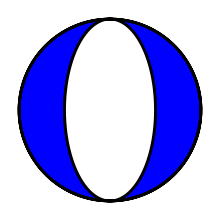

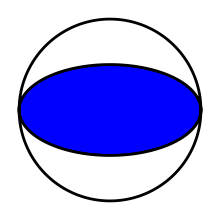

Reverse fault


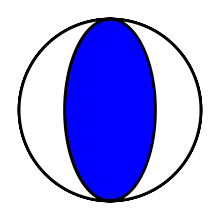

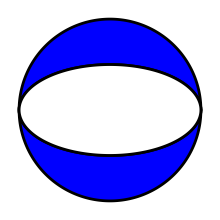

Strike-slip fault


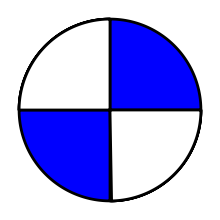

PASSED THRU EDGE CASE 3
Marco


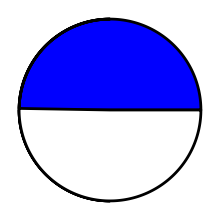

[180.   0.   0.]


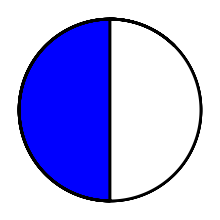

[ 0. 90. 90.]


In [103]:
# TEST CASES

azimuth = 0

# # normal fault
print("Normal fault")
strike, dip, rake = 0., 45., -90.
before = beachball([strike, dip, rake])
out1, out2 = cross_section_sdr(strike, dip, rake, azimuth)
after = beachball(out1)
# after_alt = beachball(out2)

# # reverse fault
print("Reverse fault")
strike, dip, rake = 0., 45., 90.
before = beachball([strike, dip, rake])
out1, out2 = cross_section_sdr(strike, dip, rake, azimuth)
after = beachball(out1)
# after_alt = beachball(out2)

# strike-slip fault
print("Strike-slip fault")
strike, dip, rake = 270., 90., 180.
before = beachball([strike, dip, rake])
out1, out2 = cross_section_sdr(strike, dip, rake, azimuth)
after = beachball(out1)
print(np.round(out1, 4))
after_alt = beachball(out2)
print(np.round(out2, 4))

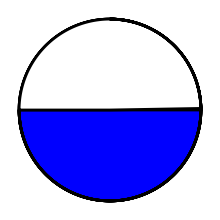

In [105]:
beachball([0,0,0]);

t: [0.5    0.5    0.7071]
p: [-0.5    -0.5     0.7071]
PASSED THRU EDGE CASE 3
Polo
sdr1: [  0.   0. 180.]


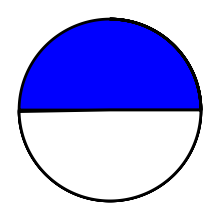

sdr2: [315.  90.  90.]


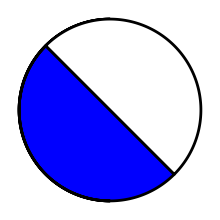

In [101]:
np.set_printoptions(precision=4)
sdr_test = [45,0,0]
t, p = sdr2tp(sdr_test, deg=True)
print("t:", np.round(t, 4))
print("p:", np.round(p, 4))
assert abs(np.dot(t, p)) < eps
sdr1, sdr2 = tp2sdr(t, p, deg=True)
print("sdr1:", np.round(sdr1, 4))
beachball(sdr1)
print("sdr2:", np.round(sdr2, 4))
beachball(sdr2);

# t1, p1 = sdr2tp(sdr1, deg=True)
# t2, p2 = sdr2tp(sdr2, deg=True)
# print("t1:", np.round(t1, 4))
# print("p1:", np.round(p1, 4))
# print("t2:", np.round(t2, 4))
# print("p2:", np.round(p2, 4))
# assert abs(np.dot(t1, p1)) < eps
# assert abs(np.dot(t2, p2)) < eps

# sdr11, sdr12 = tp2sdr(t1, p1, deg=True)
# sdr21, sdr22 = tp2sdr(t2, p2, deg=True)
# print("sdr11:", np.round(sdr11, 4))
# beachball(sdr11)
# print("sdr12:", np.round(sdr12, 4))
# beachball(sdr12)
# print("sdr21:", np.round(sdr21, 4))
# beachball(sdr21)
# print("sdr22:", np.round(sdr22, 4))
# beachball(sdr22);

In [102]:
# it's always the first one that's messed up huh